<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Customer-Success-Analytik</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Ursachenanalyse der Kundenabwanderung</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE Ursache-Wirkungs-Diagramm für eine Retention-Analyse im B2B-SaaS-Mid-Market-Segment</div>
</div>

## Zusammenfassung

Diese Analyse ordnet die Ursachentreiber der erhöhten Abwanderung von SaaS-Kunden in ein strukturiertes Ursache-Wirkungs- (Ishikawa-) Diagramm ein. Das B2B-Mid-Market-Segment wandert mit rund 18 % jährlich ab, gegenüber einem Zielwert von 8 %. Zwanzig Ursachenbefunde — aus Austrittsbefragungen, Customer-Success-Interviews und Kohortenattribution gewonnen — werden in sechs Ursachenkategorien gruppiert und mit `PROC FISHBONE` als 27-Knoten-Diagramm dargestellt (eine Wirkung, sechs Kategorie-Äste, zwanzig Unterursachen).

Die begleitende `PROC MEANS`-Aufschlüsselung zeigt, wo sich die zurechenbare Abwanderung konzentriert. **Produkt** trägt die meisten Befunde (5 Ursachen, 48,1 Gesamt-Impact-Punkte), gefolgt von **Preisgestaltung** (4 Ursachen, 42,3) und **Kundensupport** (4 Ursachen, 40,2). Gemessen am durchschnittlichen Impact *pro Ursache* ist **Wettbewerb** die schwerwiegendste Kategorie (Mittelwert 11,8), und der einzelne Befund mit dem höchsten Impact insgesamt ist die Verlängerungspreiserhöhung im Bereich **Preisgestaltung** ohne vorherige Ankündigung (14,2). Die `PROC SGPLOT`-Pareto-Ansicht rangiert jede einzelne Ursache, damit die Führung erkennen kann, welche Äste zuerst adressiert werden sollten. Das Ergebnis fließt in die vierteljährliche Retention-Übersicht des Customer-Success-Teams ein.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.CHURN_RCA | Ursachenbefunde zur Kundenabwanderung, konsolidiert aus der Austrittsbefragungsanalyse und der CS-Team-Retrospektive; jede Zeile ist eine Ursache mit Kategorie, unterstützendem Nachweis und geschätztem Abwanderungsanteil | 20 |

---

In [1]:
/* --------------------------------------------------------
   Ursachenbefunde (RCA) zur Kundenabwanderung
   SaaS-Plattform, B2B-Mid-Market-Segment.
   Jede Zeile: Ursachenkategorie, die konkrete Ursache, ein
   unterstuetzender Nachweis-Hinweis und der geschaetzte
   Anteil der darauf zurueckfuehrbaren Abwanderung (aus
   Austrittsbefragung und Kohortenattribution).
   -------------------------------------------------------- */
DATEN work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    EINGABE category :$20. cause :$100. subcause :$130. churn_impact_pct;
    DATALINES;
Produkt|Kernfunktionslücken gegenüber Enterprise-Wettbewerbern|Bulk-Export und API-Ratenlimits in 34% der Austrittsbefragungen genannt|12.4
Produkt|Eingeschränkte Reporting-Funktionen|Kein individueller Dashboard-Builder im Standardtarif|9.8
Produkt|Mobile App hinkt Webfunktionalität hinterher|3 zentrale Arbeitsabläufe können reine Mobilnutzer nicht abschließen|8.2
Produkt|Häufige UI-Änderungen ohne Ankündigung|Power-User durch vierteljährliche Redesigns gestört|7.6
Produkt|Lücken im Integrations-Marketplace|Fehlende native Salesforce- und HubSpot-Konnektoren|10.1
Preisgestaltung|Verlängerungspreiserhöhung ohne Vorwarnung|18% MRR-Erhöhung mit 30 Tagen Vorlaufzeit|14.2
Preisgestaltung|Pro-Platz-Modell benachteiligt Teamwachstum|Kosten verdoppeln sich bei Teamwachstum von 10 auf 20|11.3
Preisgestaltung|Anfangsrabatt nicht verlängerbar|Preisschock bei erster Verlängerung|9.7
Preisgestaltung|Kein Anreiz für Mehrjahresverträge|Jahrespreis identisch mit Monatspreis|7.1
Kundensupport|Erste Reaktionszeit über 24 Stunden|Tarif-Benchmark liegt bei 4 Stunden|10.8
Kundensupport|Qualitätslücke im Wochenendsupport|Offshore-Abdeckung ohne ausreichende Produktkenntnis|9.3
Kundensupport|Kein dedizierter CSM unterhalb der Enterprise-Stufe|Mid-Market-Kunden haben keinen festen Ansprechpartner|11.5
Kundensupport|Eskalationsweg für Kunden unklar|38% der abgewanderten Kunden nannten Verwirrung bei der Eskalation|8.6
Einführung|Time-to-Value über 90 Tage|Implementierungskomplexität vor Vertragsabschluss nicht offengelegt|12.9
Einführung|Selbstbedienungsdokumentation veraltet|Zuletzt vor 11 Monaten aktualisiert|8.1
Einführung|Keine In-App-Touren für neue Funktionen|Feature-Akzeptanz nach 6 Monaten unter 30%|9.4
Wettbewerb|Konkurrent 30% günstiger|Drei Großkunden nannten konkreten Wettbewerber|13.1
Wettbewerb|Konkurrent bietet Preise ohne Platzbegrenzung|Beseitigt Pro-Platz-Nachteil für wachsende Teams|10.6
Kundenbeziehung|Fluktuation des Executive Sponsors ungesteuert|Fürsprecher ist ausgeschieden; kein Reaktivierungsprogramm|11.7
Kundenbeziehung|QBR-Rhythmus auf jährlich reduziert|CS-Team-Ressourcenkürzung vor 18 Monaten|9.2
;
AUSFÜHREN;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: Konzentration der Abwanderungswirkung nach RCA-Kategorie.
   Die Summe zeigt, wo sich die zurechenbare Abwanderung buendelt;
   das Maximum kennzeichnet die schwerwiegendste Ursache je Kategorie.
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.churn_rca n sum mean MAX maxdec=1;
    KLASSE category;
    VAR churn_impact_pct;
    BEZEICHNUNG category="Kategorie" churn_impact_pct="Abwanderungsanteil (%)";
    TITEL 'Ursachenanalyse der Kundenabwanderung: Impact-Anteil nach Kategorie';
AUSFÜHREN;

                          Ursachenanalyse der Kundenabwanderung: Impact-Anteil nach Kategorie                           

                                                  The MEANS Procedure

                              Analysis Variable : churn_impact_pct Abwanderungsanteil (%)

        Kategorie                N Obs            Sum           Mean        Maximum
        ---------------------------------------------------------------------------
        Einführung                   3           30.4           10.1           12.9
        Kundenbeziehung              2           20.9           10.4           11.7
        Kundensupport                4           40.2           10.1           11.5
        Preisgestaltung              4           42.3           10.6           14.2
        Produkt                      5           48.1            9.6           12.4
        Wettbewerb                   2           23.7           11.8           13.1
        ------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                          Ursachenanalyse der Kundenabwanderung: Impact-Anteil nach Kategorie                           




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


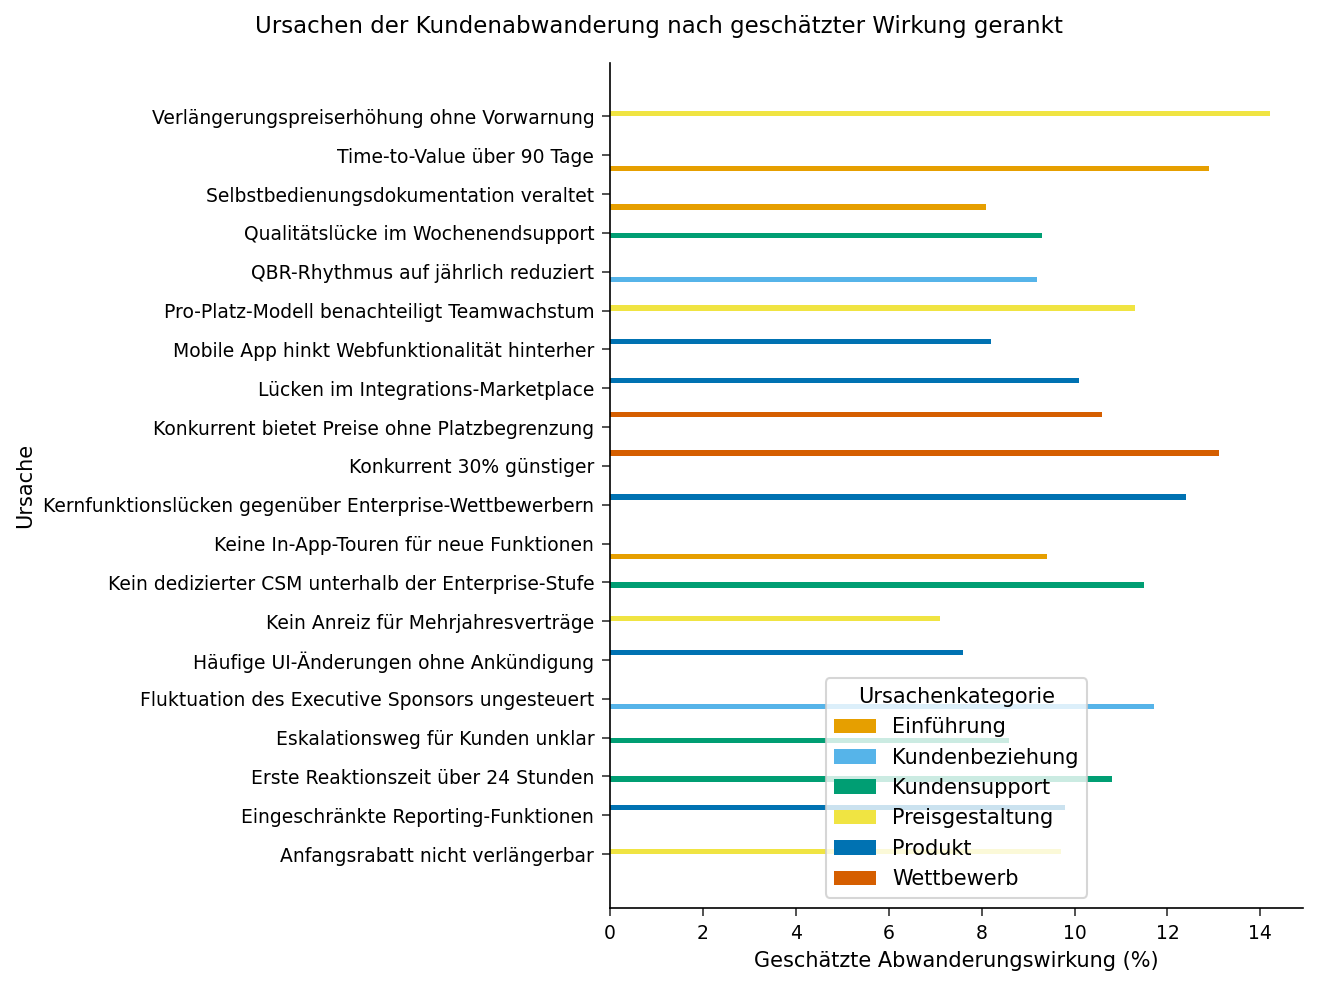

In [3]:
/* --------------------------------------------------------
   Pareto-Ansicht: einzelne Ursachen, gerankt nach geschaetzter
   Abwanderungswirkung, eingefaerbt nach Kategorie. Ergaenzt das
   Fishbone-Diagramm, indem quantifiziert wird, welche Aeste am
   wichtigsten sind.
   -------------------------------------------------------- */
PROZEDUR SORTIEREN DATEN=work.churn_rca;
    NACH ABSTEIGEND churn_impact_pct;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Geschätzte Abwanderungswirkung (%)';
    YAXIS label='Ursache' discreteorder=data;
    keylegend / title='Ursachenkategorie' position=bottom;
    TITEL 'Ursachen der Kundenabwanderung nach geschätzter Wirkung gerankt';
AUSFÜHREN;

---

### Ursache-Wirkungs- (Ishikawa-) Diagramm

`PROC FISHBONE` baut das Diagramm direkt aus `WORK.CHURN_RCA` auf: Jede unterschiedliche `category` wird zu einem Hauptast der zentralen Wirbelsäule, und die einzelnen `cause`-Befunde hängen als Unterursachen an ihrem Kategorie-Ast. Die Prozedur gibt unten die vollständige Ursache-Wirkungs-Struktur aus — die Wirkung am Kopf, die sechs Kategorie-Äste und jede Unterursache, gruppiert unter ihrem Ast — und schreibt die zugehörige Fishbone-Grafik auf die Festplatte. Das gerankte Pareto-Diagramm oben ist die begleitende Ansicht, die quantifiziert, welcher dieser Äste die meiste zurechenbare Abwanderung trägt.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: Ursache-Wirkungs-Diagramm der Kundenabwanderung.
   Das Diagramm wird direkt aus WORK.CHURN_RCA gesteuert, sodass
   die sechs Ursachenkategorien und ihre Ursachen genau den oben
   analysierten Befunden entsprechen. CATEGORY bildet die Haupt-
   Aeste; CAUSE haengt als Unterursachen an jedem Ast.
   -------------------------------------------------------- */
PROZEDUR fishbone DATEN=work.churn_rca;
    cause category / subcause=cause;
    effect 'Erhöhte Kundenabwanderung (18% jährlich gegenüber 8% Ziel)';
    TITEL 'Ursachenanalyse der Kundenabwanderung - Mid-Market-Segment';
    footnote 'Quellen: Austrittsbefragungen, CS-Team-Interviews, Kohortenattribution';
AUSFÜHREN;

                          Ursachenanalyse der Kundenabwanderung: Impact-Anteil nach Kategorie                           


                    Ursachenanalyse der Kundenabwanderung - Mid-Market-Segment
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Erhöhte Kundenabwanderung (18% jährlich gegenüber 8% Ziel)
    [CAUSE] Preisgestaltung (top)
      [SUB] Verlängerungspreiserhöhung ohne Vorwarnung
      [SUB] Pro-Platz-Modell benachteiligt Teamwachstum
      [SUB] Anfangsrabatt nicht verlängerbar
      [SUB] Kein Anreiz für Mehrjahresverträge
    [CAUSE] Wettbewerb (top)
      [SUB] Konkurrent 30% günstiger
      [SUB] Konkurrent bietet Preise ohne Platzbegrenzung
    [CAUSE] Einführung (top)
      [SUB] Time-to-Value über 90 Tage
      [SUB] Keine In-App-Touren für neue Funktionen
      [SUB] Selbstbedienungsdokumentation veraltet
    [CAUSE] Produkt (bottom)
      [SUB] Kernfunktionslücken gegenüber Enterprise-Wettbewerbern
      [SUB] Lücken im Integr


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretation

Die Ursache-Wirkungs-Struktur und die `PROC MEANS`-Kennzahlen je Kategorie weisen der Führung eine kleine Anzahl wirkungsstarker Maßnahmen. Die beiden höchsten Einzelursachen-Befunde — die **Preisgestaltung**-Verlängerungserhöhung ohne Vorwarnung (14,2) und der **Wettbewerb**-Befund, dass ein Konkurrent gleichwertige Leistung 30 % günstiger anbietet (13,1) — sind beide kommerzieller und nicht produktbezogener Natur, was darauf hindeutet, dass Preistransparenz und Wettbewerbspositionierung die dringlichsten kurzfristigen Hebel sind. Der **Einführung**-Befund „Time-to-Value über 90 Tage" (12,9) ist der größte serviceseitige Befund und hängt direkt mit der Erwartungssteuerung vor Vertragsabschluss zusammen.

Nach Volumen dominiert **Produkt** das Diagramm (5 von 20 Befunden, 48,1 Gesamt-Impact-Punkte), aber seine Befunde sind einzeln kleiner (Mittelwert 9,6) als die bei **Wettbewerb** (Mittelwert 11,8) oder **Preisgestaltung** (Mittelwert 10,6) — eine Erinnerung daran, dass eine lange Liste von Produktlücken nicht automatisch die oberste Priorität ist. Der **Kundenbeziehung**-Ast (Fluktuation des Executive Sponsors und reduzierter QBR-Rhythmus, zusammen 20,9) stellt Prozessänderungen dar, die das CS-Team innerhalb des laufenden Quartals ohne Produkt- oder Preisinvestition umsetzen kann und bietet damit den schnellsten Weg zu einer messbaren Verbesserung der Kundenbindung. Die vollständige gerankte Liste im Pareto-Diagramm erlaubt es der Führung, Maßnahmen nach geschätzter Wirkung statt nach Kategoriegröße zu priorisieren.

---

In [5]:
/* --------------------------------------------------------
   Ursachenbefunde exportieren fuer das Strategiereview-Deck
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>